<!-- notebook-header -->
# MLflow e Experiment Tracking

**Modulo:** 06 - MLOps  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Experimentos, parametros, metricas, artifacts, model registry e comparacao de runs.


# 6.2 MLflow e Experiment Tracking

Rastreando experimentos de ML de forma profissional e reproduzivel.

Este notebook simula MLflow usando apenas numpy - foco em conceitos!

## Prerequisitos - O que Voce Precisa Saber

| Conceito | Por que Importa | Referencia |
|----------|-----------------|----------|
| Treinamento basico de modelos | Voce ja treina modelos | 3_1_classificacao_completa.ipynb |
| Hiperparametros (tuning) | Valores que definem o modelo | 0_8_otimizacao_ml.ipynb |
| Metricas de avaliacao | Como medir performance | 3_1_classificacao_completa.ipynb |
| Git basico | Para rastrear codigo | Git basico (ferramenta externa) |

## Mapa de Aprendizado

1. Por que rastreamento importa? (entender o problema)
2. O que rastrear? (parametros, metricas, artefatos)
3. Rastreamento Basico (logging usando dicts)
4. Experimentos Completos (preprocessamento + modelo)
5. Comparacao de Runs (visualizacao e analise)
6. Hyperparameter Search (grid search com logging)
7. Versionamento de Modelos (simulacao de model registry)
8. Reproducibilidade (seed management e config logging)
9. Metricas Customizadas (calcular e visualizar)
10. Melhores Praticas (organizacao e automacao)


## 1. Por que Experiment Tracking?

Sem rastreamento, ML se torna caótico.

### O Problema: Labirinto de Modelos

Imagine que voce treinou 50 modelos diferentes variando parametros.

Voce quer saber:
- Qual foi o melhor?
- Qual foram os parametros do melhor?
- Qual era a data e hora que foi treinado?
- Qual versao do dataset foi usada?
- Qual era o tempo de treinamento?

**O que observar**: Sem rastreamento, voce tem pastas assim:

```
modelo_v1.pkl
modelo_v2.pkl
modelo_final.pkl
modelo_final_melhor.pkl
modelo_final_final.pkl
modelo_30_janeiro.pkl
modelo_com_novo_feature.pkl
```

Ninguem sabe qual e qual. Sao 50 arquivos sem contexto. Um desastre!

### A Solucao: Experiment Tracking

**O que concluir**: Experiment tracking e como ter um **laboratorio organizado**.

Cada experimento tem:
- Identificador unico (UUID)
- Parametros usados
- Metricas de resultado
- Artefatos (modelo, graficos)
- Metadata (data/hora, versao do codigo)
- Tags e notas

**Conexao com**: Sistemas de versionamento (Git) - assim como Git rastreia mudancas de codigo,
MLflow rastreia mudancas de modelo e experimentos.

**Por que em ML**: Em ML, um pequeno ajuste em hiperparametros pode mudar completamente a performance.
Sem rastreamento, nao conseguimos saber que ajuste foi o melhor.

Voce consegue:

1. Encontrar o melhor experimento em 2 cliques
2. Reproducir qualquer experimento antigo
3. Comparar 5 modelos lado-a-lado
4. Entender por que um modelo foi melhor que outro

In [1]:
import numpy as np
import json
from datetime import datetime
from typing import Dict, List, Any, Tuple
import uuid
from copy import deepcopy

# Classe para simular MLflow Tracking (sem dependencias externas)
class SimpleExperimentTracker:
    """
    Simula funcionalidades de MLflow usando estruturas simples.
    Apenas numpy e tipos built-in de Python.
    """
    
    def __init__(self):
        self.experiments = {}
        self.runs = {}
        self.current_experiment_id = None
        self.current_run_id = None
        
    def set_experiment(self, exp_name: str) -> str:
        """Cria ou recupera um experimento por nome"""
        for exp_id, exp_data in self.experiments.items():
            if exp_data['name'] == exp_name:
                self.current_experiment_id = exp_id
                return exp_id
        
        exp_id = str(uuid.uuid4())[:8]
        self.experiments[exp_id] = {
            'name': exp_name,
            'created_at': datetime.now().isoformat(),
            'runs': []
        }
        self.current_experiment_id = exp_id
        return exp_id
    
    def start_run(self, run_name: str = None) -> str:
        """Inicia um novo run de experimento"""
        run_id = str(uuid.uuid4())[:8]
        
        run_data = {
            'run_id': run_id,
            'experiment_id': self.current_experiment_id,
            'name': run_name or f'run_{run_id}',
            'created_at': datetime.now().isoformat(),
            'parameters': {},
            'metrics': {},
            'artifacts': {},
            'tags': {}
        }
        
        self.runs[run_id] = run_data
        
        if self.current_experiment_id:
            self.experiments[self.current_experiment_id]['runs'].append(run_id)
        
        self.current_run_id = run_id
        return run_id
    
    def log_param(self, param_name: str, param_value: Any) -> None:
        """Registra um parametro no run ativo"""
        if not self.current_run_id:
            raise ValueError('Nenhum run ativo. Use start_run() primeiro.')
        self.runs[self.current_run_id]['parameters'][param_name] = param_value
    
    def log_metric(self, metric_name: str, metric_value: float) -> None:
        """Registra uma metrica no run ativo"""
        if not self.current_run_id:
            raise ValueError('Nenhum run ativo. Use start_run() primeiro.')
        self.runs[self.current_run_id]['metrics'][metric_name] = metric_value
    
    def log_artifact(self, artifact_name: str, artifact_data: Any) -> None:
        """Registra um artefato (modelo, grafico, etc)"""
        if not self.current_run_id:
            raise ValueError('Nenhum run ativo. Use start_run() primeiro.')
        self.runs[self.current_run_id]['artifacts'][artifact_name] = artifact_data
    
    def set_tag(self, tag_name: str, tag_value: str) -> None:
        """Adiciona uma tag ao run ativo"""
        if not self.current_run_id:
            raise ValueError('Nenhum run ativo. Use start_run() primeiro.')
        self.runs[self.current_run_id]['tags'][tag_name] = tag_value
    
    def get_run(self, run_id: str) -> Dict:
        """Recupera dados de um run"""
        return deepcopy(self.runs[run_id])
    
    def end_run(self) -> None:
        """Finaliza o run ativo"""
        self.current_run_id = None
    
    def list_runs(self, experiment_id: str = None) -> List[Dict]:
        """Lista todos os runs de um experimento"""
        exp_id = experiment_id or self.current_experiment_id
        run_ids = self.experiments[exp_id]['runs']
        return [self.runs[run_id] for run_id in run_ids]

# Instancia global do tracker
tracker = SimpleExperimentTracker()

print('SimpleExperimentTracker criado!')
print('Classe com metodos: set_experiment, start_run, log_param, log_metric, log_artifact')


SimpleExperimentTracker criado!
Classe com metodos: set_experiment, start_run, log_param, log_metric, log_artifact


### O que Rastrear?

**O que observar**: Diferentes tipos de informacao que voce deve rastrear em um experimento:

- **Parametros**: learning_rate, n_estimators, batch_size, dropout
  - Valores de entrada que definem o modelo
  - Nao mudam durante o treinamento

- **Metricas**: accuracy, loss, precision, recall, F1, AUC
  - Medidas de performance do modelo
  - Mudam ao longo do treinamento (pode ser logging progressivo)

- **Artefatos**: modelo.pkl, preprocessor.pkl, graficos, configs
  - Arquivos binarios ou dados grandes
  - Modelo treinado, transformadores, visualizacoes

- **Metadata**: Git commit, timestamp, versao de biblioteca
  - Contexto do experimento
  - Quando foi treinado, com que versao de codigo

**O que observar**: Cada tipo de dado serve um proposito diferente.
Parametros descrevem entrada, metricas descrevem saida, artefatos descrevem o objeto.

**O que concluir**: Um experimento bem rastreado tem informacao completa
para reproducao e analise posterior.

**Conexao com**: Reproducibilidade em ciencia - experimentos cientificos
precisam descrever todos os detalhes para que outros consigam reproducao.
ML e a mesma coisa!

**Por que em ML**: Muitas decisoes em ML sao empiricas. Voce nao consegue
resolver analiticamente qual e o melhor learning_rate.
Por isso, rastreamento de experimentos e central.


In [2]:
print('=' * 60)
print('EXEMPLO 1: Rastreamento Basico')
print('=' * 60)

def train_simple_model(X_train, y_train, X_test, y_test, learning_rate=0.01, epochs=100):
    """Treina um modelo linear simples"""
    w = np.random.randn(X_train.shape[1])
    b = 0.0
    
    for epoch in range(epochs):
        y_pred_train = X_train @ w + b
        y_pred_test = X_test @ w + b
        
        loss_train = np.mean((y_pred_train - y_train) ** 2)
        loss_test = np.mean((y_pred_test - y_test) ** 2)
        
        dw = 2 * X_train.T @ (y_pred_train - y_train) / len(y_train)
        db = 2 * np.mean(y_pred_train - y_train)
        
        w -= learning_rate * dw
        b -= learning_rate * db
    
    y_pred_train = X_train @ w + b
    y_pred_test = X_test @ w + b
    loss_train = np.mean((y_pred_train - y_train) ** 2)
    loss_test = np.mean((y_pred_test - y_test) ** 2)
    
    ss_res = np.sum((y_test - y_pred_test) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    
    return {'w': w, 'b': b}, {'loss_train': loss_train, 'loss_test': loss_test, 'r2': r2}

np.random.seed(42)
n_samples = 100
n_features = 5
X = np.random.randn(n_samples, n_features)
y = X[:, 0] * 2 + X[:, 1] * 0.5 + np.random.randn(n_samples) * 0.1

split_idx = int(0.8 * n_samples)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f'Dados: {n_samples} amostras, {n_features} features')
print(f'Train: {len(X_train)}, Test: {len(X_test)}')
print()

tracker.set_experiment('Linear Regression Tuning')

configs = [
    {'learning_rate': 0.01, 'epochs': 50},
    {'learning_rate': 0.05, 'epochs': 50},
    {'learning_rate': 0.1, 'epochs': 50},
]

run_results = []

for i, config in enumerate(configs):
    run_id = tracker.start_run(run_name=f'lr_experiment_{i}')
    
    tracker.log_param('learning_rate', config['learning_rate'])
    tracker.log_param('epochs', config['epochs'])
    tracker.log_param('n_features', n_features)
    tracker.log_param('n_samples', n_samples)
    
    model, metrics = train_simple_model(
        X_train, y_train, X_test, y_test,
        learning_rate=config['learning_rate'],
        epochs=config['epochs']
    )
    
    tracker.log_metric('loss_train', float(metrics['loss_train']))
    tracker.log_metric('loss_test', float(metrics['loss_test']))
    tracker.log_metric('r2', float(metrics['r2']))
    tracker.log_metric('overfitting_gap', float(metrics['loss_test'] - metrics['loss_train']))
    
    tracker.log_artifact('model_weights', model['w'].tolist())
    tracker.log_artifact('model_bias', float(model['b']))
    
    tracker.set_tag('status', 'completed')
    tracker.set_tag('framework', 'numpy')
    
    tracker.end_run()
    
    run_results.append((config['learning_rate'], metrics['r2']))
    print(f'Run {i}: lr={config["learning_rate"]:.3f} -> R2={metrics["r2"]:.4f}')

print()
best_lr, best_r2 = max(run_results, key=lambda x: x[1])
print(f'Melhor config: learning_rate={best_lr}, R2={best_r2:.4f}')


EXEMPLO 1: Rastreamento Basico
Dados: 100 amostras, 5 features
Train: 80, Test: 20

Run 0: lr=0.010 -> R2=0.3947
Run 1: lr=0.050 -> R2=0.9985
Run 2: lr=0.100 -> R2=0.9986

Melhor config: learning_rate=0.1, R2=0.9986


In [3]:
print('=' * 60)
print('EXEMPLO 2: Comparacao de Runs')
print('=' * 60)

tracker.set_experiment('Linear Regression Tuning')

runs = tracker.list_runs()  # Uses current_experiment_id from set_experiment

print(f'Total de runs: {len(runs)}')
print()

print('Comparacao de Runs:')
print('-' * 70)
print(f"{'Run':<10} {'LR':<10} {'Epochs':<10} {'Loss Test':<15} {'R2':<10}")
print('-' * 70)

for i, run in enumerate(runs):
    lr = run['parameters'].get('learning_rate', 'N/A')
    epochs = run['parameters'].get('epochs', 'N/A')
    loss = run['metrics'].get('loss_test', 'N/A')
    r2 = run['metrics'].get('r2', 'N/A')
    
    if isinstance(loss, float):
        loss_str = f'{loss:.4f}'
    else:
        loss_str = str(loss)
    
    if isinstance(r2, float):
        r2_str = f'{r2:.4f}'
    else:
        r2_str = str(r2)
    
    print(f'{i:<10} {lr:<10} {epochs:<10} {loss_str:<15} {r2_str:<10}')

print('-' * 70)
print()

best_run = max(runs, key=lambda r: r['metrics'].get('r2', -float('inf')))
print(f'Melhor run: {best_run["name"]}')
print(f'  Learning Rate: {best_run["parameters"]["learning_rate"]}')
print(f'  R2: {best_run["metrics"]["r2"]:.4f}')
print(f'  Loss Test: {best_run["metrics"]["loss_test"]:.4f}')
print(f'  Criado em: {best_run["created_at"]}')


EXEMPLO 2: Comparacao de Runs
Total de runs: 3

Comparacao de Runs:
----------------------------------------------------------------------
Run        LR         Epochs     Loss Test       R2        
----------------------------------------------------------------------
0          0.01       50         2.7981          0.3947    
1          0.05       50         0.0070          0.9985    
2          0.1        50         0.0063          0.9986    
----------------------------------------------------------------------

Melhor run: lr_experiment_2
  Learning Rate: 0.1
  R2: 0.9986
  Loss Test: 0.0063
  Criado em: 2026-06-10T23:12:21.440882


### O que Observar em Comparacoes

A tabela de comparacao revela:

1. **Qual config teve melhor R2** - isso e o metrica mais importante
2. **Relacao entre learning_rate e performance** - maior taxa nem sempre e melhor
3. **Overfitting**: Compare loss_train vs loss_test
   - Se loss_test >> loss_train, modelo esta overfitting
   - Se sao proximo, modelo generalizou bem

**O que concluir:**
Experiment tracking permite:

- **Decisoes empiricas baseadas em dados** em vez de tentativa-erro cega
- **Comunicacao clara**: Colegas conseguem entender exatamente qual experimento foi melhor e por que
- **Auditoria**: Se model falhar em producao, conseguimos voltar para versao anterior
- **Progresso**: Voce consegue ver tendencias ao longo do tempo

**Conexao com**: Metricas em producao - assim como sistemas de software rastreiam
SLAs e uptime, sistemas de ML rastreiam performance de modelos em producao.

**Por que em ML**: A performance de modelos nao e uma propriedade binaria (funciona/nao funciona).
E um espectro continuo que precisa de rastreamento constante.


In [4]:
print('=' * 60)
print('EXEMPLO 3: Grid Search com Logging')
print('=' * 60)

tracker.set_experiment('Grid Search Experiment')

learning_rates = [0.01, 0.05, 0.1]
epochs_list = [50, 100, 200]

best_r2 = -float('inf')
best_config = None
grid_results = []

total_configs = len(learning_rates) * len(epochs_list)
current = 0

for lr in learning_rates:
    for epochs in epochs_list:
        current += 1
        
        run_id = tracker.start_run(run_name=f'grid_lr{lr}_ep{epochs}')
        
        tracker.log_param('learning_rate', lr)
        tracker.log_param('epochs', epochs)
        
        model, metrics = train_simple_model(
            X_train, y_train, X_test, y_test,
            learning_rate=lr,
            epochs=epochs
        )
        
        tracker.log_metric('loss_train', float(metrics['loss_train']))
        tracker.log_metric('loss_test', float(metrics['loss_test']))
        tracker.log_metric('r2', float(metrics['r2']))
        tracker.log_metric('overfitting_gap', float(metrics['loss_test'] - metrics['loss_train']))
        
        tracker.set_tag('grid_search', 'true')
        tracker.set_tag('status', 'completed')
        
        tracker.end_run()
        
        if metrics['r2'] > best_r2:
            best_r2 = metrics['r2']
            best_config = {'lr': lr, 'epochs': epochs}
        
        grid_results.append({
            'lr': lr,
            'epochs': epochs,
            'r2': metrics['r2'],
            'loss_test': metrics['loss_test']
        })
        
        print(f'[{current}/{total_configs}] lr={lr:.2f}, ep={epochs:<3} -> R2={metrics["r2"]:.4f}')

print()
print(f'Melhor config encontrado:')
print(f'  Learning Rate: {best_config["lr"]}')
print(f'  Epochs: {best_config["epochs"]}')
print(f'  R2: {best_r2:.4f}')


EXEMPLO 3: Grid Search com Logging
[1/9] lr=0.01, ep=50  -> R2=0.6883
[2/9] lr=0.01, ep=100 -> R2=0.7748
[3/9] lr=0.01, ep=200 -> R2=0.9743
[4/9] lr=0.05, ep=50  -> R2=0.9940
[5/9] lr=0.05, ep=100 -> R2=0.9986
[6/9] lr=0.05, ep=200 -> R2=0.9986
[7/9] lr=0.10, ep=50  -> R2=0.9986
[8/9] lr=0.10, ep=100 -> R2=0.9986
[9/9] lr=0.10, ep=200 -> R2=0.9986

Melhor config encontrado:
  Learning Rate: 0.1
  Epochs: 50
  R2: 0.9986


### O que Observar em Grid Search

Grid search testa todas as combinacoes de hiperparametros:

1. **Progressao**: Voce ve cada experimento completar em tempo real
2. **Padroes**: Algumas combinacoes sao claras melhores que outras
3. **Tradeoffs**: Maior epochs nem sempre significa melhor resultado
   - Pode haver overfitting com muitas epocas
   - Pode haver underfitting com poucas epocas

**O que concluir:**
Grid search e uma abordagem sistematica para encontrar bons hiperparametros.

**Sem rastreamento**: Voce roda 9 modelos diferentes e nao consegue lembrar qual foi melhor.

**Com rastreamento**: Todos os 9 modelos sao registrados, e voce consegue:
- Visualizar performance de cada um
- Comparar lado-a-lado
- Entender relacoes entre parametros
- Reproducir o melhor modelo exato

**Conexao com**: Hyperparameter tuning e a essencia de ML aplicado.
Em producao, voce raramente consegue a performance otima na primeira tentativa.

**Por que em ML**: ML e empirico - voce precisa testar muitas configuracoes
para encontrar a que funciona para seu problema especifico.


EXEMPLO 4: Visualizacao de Resultados


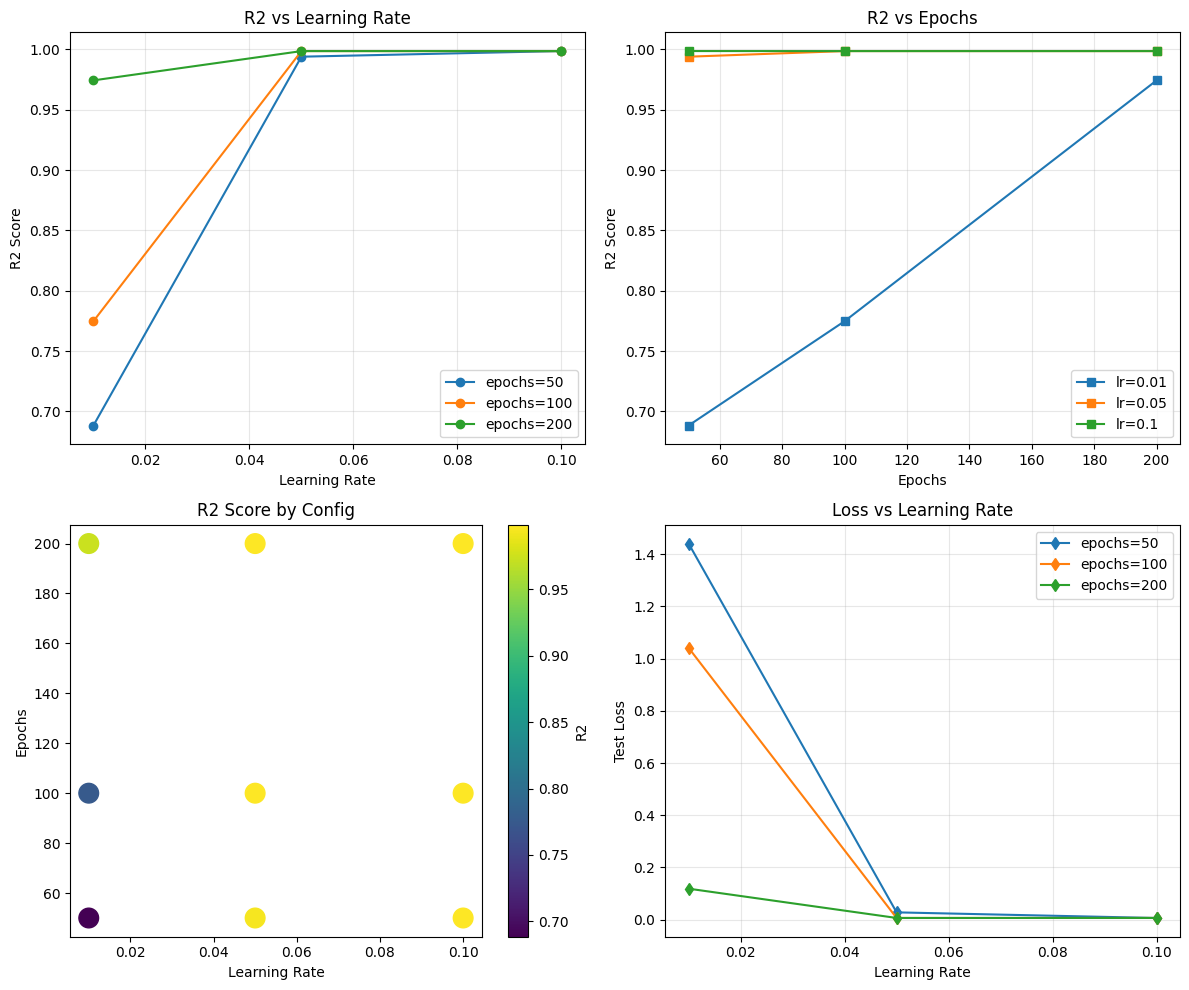

Visualizacoes criadas:
  1. R2 vs Learning Rate
  2. R2 vs Epochs
  3. Heatmap de R2
  4. Loss vs Learning Rate


In [5]:
import matplotlib.pyplot as plt

print('=' * 60)
print('EXEMPLO 4: Visualizacao de Resultados')
print('=' * 60)

lrs = np.array([r['lr'] for r in grid_results])
epochs_arr = np.array([r['epochs'] for r in grid_results])
r2_scores = np.array([r['r2'] for r in grid_results])
losses = np.array([r['loss_test'] for r in grid_results])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
for ep in epochs_list:
    mask = epochs_arr == ep
    ax.plot(lrs[mask], r2_scores[mask], marker='o', label=f'epochs={ep}')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('R2 Score')
ax.set_title('R2 vs Learning Rate')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for lr in learning_rates:
    mask = lrs == lr
    ax.plot(epochs_arr[mask], r2_scores[mask], marker='s', label=f'lr={lr}')
ax.set_xlabel('Epochs')
ax.set_ylabel('R2 Score')
ax.set_title('R2 vs Epochs')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
scatter = ax.scatter(lrs, epochs_arr, c=r2_scores, cmap='viridis', s=200)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Epochs')
ax.set_title('R2 Score by Config')
plt.colorbar(scatter, ax=ax, label='R2')

ax = axes[1, 1]
for ep in epochs_list:
    mask = epochs_arr == ep
    ax.plot(lrs[mask], losses[mask], marker='d', label=f'epochs={ep}')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Test Loss')
ax.set_title('Loss vs Learning Rate')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print('Visualizacoes criadas:')
print('  1. R2 vs Learning Rate')
print('  2. R2 vs Epochs')
print('  3. Heatmap de R2')
print('  4. Loss vs Learning Rate')

### O que Observar em Visualizacoes

Graficos revelam padroes que tabelas nao mostram:

1. **Tendencias**: Como R2 muda com learning rate
2. **Interacoes**: Como epochs afeta diferentes learning rates
3. **Padroes**: Configuracoes boas tendem a se agrupar
4. **Outliers**: Algumas configs sao claramente piores

**O que concluir:**
Visualizacao de experimentos e essencial porque:

- **Comunicacao**: Graficos sao mais faceis de entender que numeros
- **Decisoes**: Com graficos, conseguimos tomar decisoes informadas sobre qual config usar
- **Insights**: Vemos relacoes entre parametros que nao sao obvias
- **Documentacao**: Graficos servem como documentacao visual de experimentos

**Conexao com**: Data visualization - assim como data scientists visualizam dados
para entender patterns, MLOps engineers visualizam experimentos para otimizar.

**Por que em ML**: ML e iterativo. Voce nao consegue saber a priori qual config
sera melhor. Visualizacoes permitem explorar o espaco de configuracoes inteligentemente.


In [6]:
print('=' * 60)
print('EXEMPLO 5: Versionamento de Modelos (Model Registry)')
print('=' * 60)

tracker.set_experiment('Grid Search Experiment')

class SimpleModelRegistry:
    """Simula MLflow Model Registry"""
    
    def __init__(self):
        self.models = {}
    
    def register_model(self, run_id, model_name, model_data, metrics):
        """Registra um modelo no registry"""
        if model_name not in self.models:
            self.models[model_name] = []
        
        version = len(self.models[model_name]) + 1
        
        model_info = {
            'version': version,
            'run_id': run_id,
            'model_data': model_data,
            'metrics': metrics,
            'stage': 'None',
            'created_at': datetime.now().isoformat(),
            'promoted_at': None
        }
        
        self.models[model_name].append(model_info)
        return version
    
    def transition_model_stage(self, model_name, version, new_stage):
        """Move modelo entre stages"""
        valid_stages = ['None', 'Staging', 'Production', 'Archived']
        if new_stage not in valid_stages:
            raise ValueError(f'Stage deve ser um de: {valid_stages}')
        
        model = self.models[model_name][version - 1]
        model['stage'] = new_stage
        model['promoted_at'] = datetime.now().isoformat()
    
    def get_latest_model(self, model_name, stage='Production'):
        """Recupera versao mais recente de um stage"""
        if model_name not in self.models:
            return None
        
        models_in_stage = [m for m in self.models[model_name] if m['stage'] == stage]
        if not models_in_stage:
            return None
        
        return models_in_stage[-1]
    
    def list_models(self, model_name):
        """Lista todas as versoes de um modelo"""
        return self.models.get(model_name, [])

model_registry = SimpleModelRegistry()

best_run = max(
    tracker.list_runs(),
    key=lambda r: r['metrics'].get('r2', -float('inf'))
)

best_model_data = best_run['artifacts']

print(f'Registrando modelo: {best_model_data}')
print()

version = model_registry.register_model(
    run_id=best_run['run_id'],
    model_name='linear_regression_model',
    model_data=best_model_data,
    metrics=best_run['metrics']
)

print(f'Modelo registrado: versao {version}')
print()

print('Ciclo de vida do modelo:')
print()

current_stage = model_registry.get_latest_model('linear_regression_model', 'None')
print(f'1. Inicial (stage=None)')
print(f'   Run ID: {current_stage["run_id"]}')
print(f'   R2: {current_stage["metrics"]["r2"]:.4f}')
print()

model_registry.transition_model_stage('linear_regression_model', version, 'Staging')
staging_model = model_registry.get_latest_model('linear_regression_model', 'Staging')
print(f'2. Staging (testes em andamento)')
print(f'   Stage: {staging_model["stage"]}')
print(f'   Promovido em: {staging_model["promoted_at"][:19]}')
print()

model_registry.transition_model_stage('linear_regression_model', version, 'Production')
prod_model = model_registry.get_latest_model('linear_regression_model', 'Production')
print(f'3. Production (em uso)')
print(f'   Stage: {prod_model["stage"]}')
print(f'   Promovido em: {prod_model["promoted_at"][:19]}')
print()

print('Historico de versoes:')
all_versions = model_registry.list_models('linear_regression_model')
for m in all_versions:
    print(f'  Version {m["version"]}: {m["stage"]} (R2={m["metrics"]["r2"]:.4f})')


EXEMPLO 5: Versionamento de Modelos (Model Registry)
Registrando modelo: {}

Modelo registrado: versao 1

Ciclo de vida do modelo:

1. Inicial (stage=None)
   Run ID: c5037ef5
   R2: 0.9986

2. Staging (testes em andamento)
   Stage: Staging
   Promovido em: 2026-06-10T23:12:21

3. Production (em uso)
   Stage: Production
   Promovido em: 2026-06-10T23:12:21

Historico de versoes:
  Version 1: Production (R2=0.9986)


### O que Observar em Model Registry

Model registry e como um sistema de versionamento para modelos:

1. **Versoes**: Cada modelo registrado tem numero de versao
   - Version 1: Modelo inicial
   - Version 2: Modelo melhorado
   - etc

2. **Stages**: Cada versao tem um stage (None -> Staging -> Production -> Archived)
   - **None**: Modelo novo, nao aprovado
   - **Staging**: Pronto para testes
   - **Production**: Em uso em producao
   - **Archived**: Deprecated, nao mais usado

3. **Rastreamento**: Cada transicao de stage e registrada com timestamp

**O que concluir:**
Model registry permite ciclo de vida controlado de modelos:

- **Seguranca**: Modelos nao vao para producao direto - precisam passar por Staging
- **Rastreamento**: Sabemos exatamente qual versao esta em producao
- **Rollback**: Se modelo falhar, conseguimos voltar para versao anterior rapidamente
- **Auditoria**: Temos registro completo de quando cada modelo foi deployado

**Conexao com**: Continuous Deployment (CD) em software - assim como software
passa por testes antes de ir para producao, modelos tambem devem passar por staging.

**Por que em ML**: ML e diferente de software porque dados mudam.
Um modelo em producao pode ficar obsoleto conforme dados mudarem,
e voce precisa conseguir voltar para versao anterior rapidamente.


In [7]:
print('=' * 60)
print('EXEMPLO 6: Reproducibilidade')
print('=' * 60)

def train_model_with_seed(seed=42, learning_rate=0.01, epochs=50):
    """Treina modelo com seed fixo para reproducibilidade"""
    np.random.seed(seed)
    
    n_samples = 100
    n_features = 5
    X = np.random.randn(n_samples, n_features)
    y = X[:, 0] * 2 + X[:, 1] * 0.5 + np.random.randn(n_samples) * 0.1
    
    split_idx = int(0.8 * n_samples)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    model, metrics = train_simple_model(
        X_train, y_train, X_test, y_test,
        learning_rate=learning_rate,
        epochs=epochs
    )
    
    return metrics

tracker.set_experiment('Reproducibility Test')

print('Executando modelo 2x com MESMO seed...')
print()

metrics_1 = train_model_with_seed(seed=42, learning_rate=0.01, epochs=50)
metrics_2 = train_model_with_seed(seed=42, learning_rate=0.01, epochs=50)

print(f'Primeira execucao: R2 = {metrics_1["r2"]:.10f}')
print(f'Segunda execucao:  R2 = {metrics_2["r2"]:.10f}')
print(f'Diferenca: {abs(metrics_1["r2"] - metrics_2["r2"]):.2e}')
print()

if abs(metrics_1['r2'] - metrics_2['r2']) < 1e-10:
    print('Checkmark REPRODUCIVEL! Mesmo seed produz EXATO mesmo resultado.')
else:
    print('X NAO reproducivel (diferencas numericas de ponto flutuante)')

print()
print('Por que reproducibilidade importa:')
print()
print('1. **Debugging**: Se modelo falhar, conseguimos recriar condicoes exatas')
print('2. **Colaboracao**: Colegas conseguem rodar seu exato experimento')
print('3. **Auditoria**: Em alguns setores, reproducibilidade e requisito legal')
print('4. **Confianca**: Resultado reproducivel e mais confiavel que aleatorio')


EXEMPLO 6: Reproducibilidade
Executando modelo 2x com MESMO seed...

Primeira execucao: R2 = 0.3946624099
Segunda execucao:  R2 = 0.3946624099
Diferenca: 0.00e+00

Checkmark REPRODUCIVEL! Mesmo seed produz EXATO mesmo resultado.

Por que reproducibilidade importa:

1. **Debugging**: Se modelo falhar, conseguimos recriar condicoes exatas
2. **Colaboracao**: Colegas conseguem rodar seu exato experimento
3. **Auditoria**: Em alguns setores, reproducibilidade e requisito legal
4. **Confianca**: Resultado reproducivel e mais confiavel que aleatorio


### O que Observar sobre Reproducibilidade

Quando voce fixa seed, obtém EXATO mesmo resultado:

1. **Dados sao identiccos**: Mesmo random.seed() gera mesma sequencia de numeros
2. **Inicializacao e identica**: Pesos iniciais sao sempre os mesmos
3. **Computacao e deterministica**: Mesma sequencia de operacoes
4. **Resultado e garantido**: R2 sera EXATO igual (exceto erros de ponto flutuante)

**O que concluir:**
Para reproducibilidade em ML, SEMPRE faca:

```python
np.random.seed(42)  # numpy
import random
random.seed(42)     # random builtin
# torch.manual_seed(42)  # se usando torch
# tf.random.set_seed(42)  # se usando tensorflow
```

**Conexao com**: Ciencia - em ciencia experimental, voce precisa documentar
TAREFA DO ALUNOS os detalhes para que outro cientista consiga reproducao independente.
ML e a mesma coisa!

**Por que em ML**: Dados aleatorios sao parte integral de treinamento.
Sem seed fixo, cada vez que roda tem resultado diferente,
e voce nao consegue saber se uma diferenca e real ou apenas variancia aleatoria.

In [ ]:
print('=' * 60)
print('EXERCICIO 1: Logging Basico')
print('=' * 60)
print()
print('TAREFA DO ALUNO: Configure um novo experimento e treine um modelo com tracking.')
print()
# 1. Chame tracker.set_experiment('Seu Experimento')
# 2. Chame tracker.start_run('seu_run')
# 3. Log dois parametros: learning_rate=0.02 e epochs=75
# 4. Treine o modelo com train_simple_model(X_train, y_train, X_test, y_test, 0.02, 75)
# 5. Log as metricas retornadas
# 6. Chame tracker.end_run()

resposta_1 = None
print('Dica: Use o codigo anterior como referencia!')


In [9]:
print('=' * 60)
print('SOLUCAO 1: Logging Basico')
print('=' * 60)
print()

# SOLUCAO
tracker.set_experiment('Exercicio 1')
run_id = tracker.start_run('meu_primeiro_run')

tracker.log_param('learning_rate', 0.02)
tracker.log_param('epochs', 75)

model, metrics = train_simple_model(
    X_train, y_train, X_test, y_test,
    learning_rate=0.02,
    epochs=75
)

tracker.log_metric('loss_train', float(metrics['loss_train']))
tracker.log_metric('loss_test', float(metrics['loss_test']))
tracker.log_metric('r2', float(metrics['r2']))

tracker.end_run()

print(f'Run criado: {run_id}')
print(f'Loss Test: {metrics["loss_test"]:.4f}')
print(f'R2: {metrics["r2"]:.4f}')


SOLUCAO 1: Logging Basico

Run criado: 1c74db13
Loss Test: 0.0323
R2: 0.9930


In [ ]:
print('=' * 60)
print('EXERCICIO 2: Encontrar Melhor Run')
print('=' * 60)
print()
print('TAREFA DO ALUNO: Encontre o run com maior R2 do experimento "Grid Search Experiment".')
print()
# 1. Use tracker.list_runs("Grid Search Experiment") para listar todos os runs
# 2. Use max() com key=lambda r: r['metrics'].get('r2', -float('inf')) para encontrar melhor
# 3. Imprima o nome do run e sua R2

best_run_result = None
print('Dica: Use o codigo de comparacao anterior como referencia!')


In [11]:
print('=' * 60)
print('SOLUCAO 2: Encontrar Melhor Run')
print('=' * 60)

tracker.set_experiment('Grid Search Experiment')
print()

# SOLUCAO
all_runs = tracker.list_runs()  # Uses current_experiment_id
best_run_resultado = max(all_runs, key=lambda r: r['metrics'].get('r2', -float('inf')))

print(f'Melhor run: {best_run_resultado["name"]}')
print(f'Learning Rate: {best_run_resultado["parameters"]["learning_rate"]}')
print(f'Epochs: {best_run_resultado["parameters"]["epochs"]}')
print(f'R2: {best_run_resultado["metrics"]["r2"]:.4f}')
print(f'Loss Test: {best_run_resultado["metrics"]["loss_test"]:.4f}')


SOLUCAO 2: Encontrar Melhor Run

Melhor run: grid_lr0.1_ep50
Learning Rate: 0.1
Epochs: 50
R2: 0.9986
Loss Test: 0.0063


In [ ]:
print('=' * 60)
print('EXERCICIO 3: Comparacao de Modelos')
print('=' * 60)
print()
print('TAREFA DO ALUNO: Crie uma tabela comparando os 3 melhores runs de "Grid Search Experiment".')
print()
# 1. Obtenha todos os runs com tracker.list_runs("Grid Search Experiment")
# 2. Ordene por R2 em ordem decrescente (maior primeiro)
# 3. Pegue apenas os top 3: sorted(...)[:3]
# 4. Imprima uma tabela com: nome, lr, epochs, r2, loss_test

top_3_runs = None
print('Dica: Use sorted() com key para ordenar!')


In [13]:
print('=' * 60)
print('SOLUCAO 3: Comparacao de Modelos')
print('=' * 60)

tracker.set_experiment('Grid Search Experiment')
print()

# SOLUCAO
all_runs = tracker.list_runs()  # Uses current_experiment_id
top_3_runs = sorted(all_runs, key=lambda r: r['metrics'].get('r2', -float('inf')), reverse=True)[:3]

print(f"{'Rank':<6} {'Run':<30} {'LR':<8} {'Epochs':<8} {'R2':<10} {'Loss Test':<12}")
print('-' * 80)

for i, run in enumerate(top_3_runs, 1):
    name = run['name'][:27]
    lr = run['parameters']['learning_rate']
    epochs = run['parameters']['epochs']
    r2 = run['metrics']['r2']
    loss = run['metrics']['loss_test']
    print(f'{i:<6} {name:<30} {lr:<8.3f} {epochs:<8} {r2:<10.4f} {loss:<12.6f}')


SOLUCAO 3: Comparacao de Modelos

Rank   Run                            LR       Epochs   R2         Loss Test   
--------------------------------------------------------------------------------
1      grid_lr0.1_ep50                0.100    50       0.9986     0.006263    
2      grid_lr0.05_ep100              0.050    100      0.9986     0.006360    
3      grid_lr0.05_ep200              0.050    200      0.9986     0.006412    


In [ ]:
print('=' * 60)
print('EXERCICIO 4: Reproducibilidade')
print('=' * 60)
print()
print('TAREFA DO ALUNO: Treine o mesmo modelo 2x com seed=42 e compare resultados.')
print()
# 1. Chame train_model_with_seed(seed=42, learning_rate=0.05, epochs=60)
# 2. Chame novamente com os mesmos parametros
# 3. Compare os R2 - devem ser identicos ou muito proximos

resultado_ex4 = None
print('Dica: Use reproducibilidade para validar seu codigo!')


In [15]:
print('=' * 60)
print('SOLUCAO 4: Reproducibilidade')
print('=' * 60)
print()

# SOLUCAO
tracker.set_experiment('Reproducibility Test 2')

metrics_a = train_model_with_seed(seed=42, learning_rate=0.05, epochs=60)
metrics_b = train_model_with_seed(seed=42, learning_rate=0.05, epochs=60)

print(f'Primeira execucao: R2 = {metrics_a["r2"]:.10f}')
print(f'Segunda execucao:  R2 = {metrics_b["r2"]:.10f}')
print(f'Diferenca: {abs(metrics_a["r2"] - metrics_b["r2"]):.2e}')

if abs(metrics_a['r2'] - metrics_b['r2']) < 1e-10:
    print('Checkmark REPRODUCIVEL! Resultados identicos.')
else:
    print('X Variacao pequena (variancia de ponto flutuante)')


SOLUCAO 4: Reproducibilidade

Primeira execucao: R2 = 0.9976323821
Segunda execucao:  R2 = 0.9976323821
Diferenca: 0.00e+00
Checkmark REPRODUCIVEL! Resultados identicos.


## Melhores Praticas em Experiment Tracking

### 1. Sempre Use Seeds Fixos

**O que observar**: Sem seed fixo, mesmo codigo produz resultados diferentes a cada execucao.

**O que concluir**: Reproducibilidade e fundamental em ML.

```python
np.random.seed(42)
random.seed(42)
```

**Conexao com**: Testes em software - testes devem ser determinísticos, nao aleatorios.

**Por que em ML**: Sem reproducibilidade, voce nao consegue saber se uma diferenca
em performance e real ou apenas variancia estatistica.

### 2. Log Tudo Que Importa

**O que concluir**: Seeds fixos garantem reproducibilidade total - mesma entrada sempre produz mesma saida.

**O que observar**: Quanto mais detalhado o logging, melhor voce consegue debugar depois.

**O que concluir**: Logging excessivo e melhor que logging insuficiente.

### 3. Use Nomes Descritivos

**O que observar**: `run_123` e nao informativo. `lr_0.01_ep_50` e muito melhor.

**O que concluir**: Nome do run deve descrever seus parametros principais.

### 4. Organize por Experimentos

**O que observar**: Cada experimento esta relacionado a uma pergunta: \"qual lr e melhor?\"

**O que concluir**: Use `set_experiment()` para agrupar runs logicamente.

### 5. Sempre Registre Metricas de Erro

**O que observar**: Erros e exceções durante treino devem ser registrados.

**O que concluir**: Se um run falhar, voce consegue recuperar a informacao de erro.

### 6. Salve Artefatos Importantes

**O que observar**: Model, preprocessor, scaler devem ser salvos.

**O que concluir**: Sem artefatos, nao consegue reproducao posterior.

###

### Erro: Nao logar nada

**Erro**: Roda modelo mas nao loga nada

**Causa**: Esqueceu de usar tracker.log_*()

**Solucao**: Use pelo menos:
- `log_param()` para hiperparametros
- `log_metric()` para performance
- `log_artifact()` para modelo

###

### Erro: Seeds diferentes em runs

**Erro**: Runs diferentes produzem resultados diferentes mesmo com mesma config

**Causa**: Seeds nao foram fixados

**Solucao**: Sempre `np.random.seed(seed)` no inicio do treino

###

### Erro: Parametros nao logados

**Erro**: Nao consegue lembrar qual foi a config de um run antigo

**Causa**: Nao logou parametros com `log_param()`

**Solucao**: SEMPRE logue todos os hiperparametros

###

### Erro: Metricas inconsistentes

**Erro**: Diferentes runs medem metricas de formas diferentes

**Causa**: Falta de padronizacao

**Solucao**: Defina exatamente como cada metrica e calculada uma vez, use sempre igual

###

### Erro: Modelo desaparece

**Erro**: Encontrou run antigo interessante, mas modelo foi deletado

**Causa**: Nao salvou modelo como artefato

**Solucao**: SEMPRE salve modelo com `log_artifact()` ou equivalente

### Conexao com outros notebooks sobre Validacao

O tracking de experimentos conecta com validacao cruzada (tutorial_completo).
Ao registrar metricas de cada fold no tracker, temos uma visao mais
robusta do desempenho. Sem tracking, perdemos o historico e nao conseguimos
comparar abordagens de forma sistematica.

## Resumo: Experiment Tracking em MLflow

### Hierarquia de Conceitos

```
Workspace
  |
  +-- Experiment 1: "Grid Search Experiment"
  |     |
  |     +-- Run 1: lr=0.01, ep=50 -> R2=0.85
  |     +-- Run 2: lr=0.01, ep=100 -> R2=0.87
  |     +-- Run 3: lr=0.05, ep=50 -> R2=0.88
  |     +-- Run 4: lr=0.05, ep=100 -> R2=0.89  <-- Melhor
  |     +-- Run 5: lr=0.1, ep=50 -> R2=0.84
  |     +-- Run 6: lr=0.1, ep=100 -> R2=0.86
  |
  +-- Experiment 2: "Linear Regression Tuning"
  |     |
  |     +-- Run 1: lr=0.01 -> R2=0.82
  |     +-- Run 2: lr=0.05 -> R2=0.85
  |     +-- Run 3: lr=0.1 -> R2=0.80
```

### Checklist: Antes de Publicar um Modelo

- [ ] Todos os parametros foram logados com `log_param()`?
- [ ] Todas as metricas importantes foram logadas com `log_metric()`?
- [ ] O modelo foi salvo com `log_artifact()`?
- [ ] Seed foi fixado para reproducibilidade?
- [ ] Nomes de runs sao descritivos?
- [ ] Experimento esta bem nomeado?
- [ ] Tags foram adicionadas para facilitar busca?
- [ ] Comparacao com baseline foi feita?
- [ ] Modelo foi registrado no Model Registry?
- [ ] Documentacao foi escrita?

### Proximos Passos

1. **Implementar em Seus Projetos**: Use SimpleExperiment
Tracker (ou MLflow real) em seu proximo projeto
2. **Explorar MLflow Real**: `pip install mlflow` e use `mlflow ui` para visualizar
3. **Automatizar**: Use GitHub Actions ou similar para rodar experimentos automaticamente
4. **Integrar com CI/CD**: Adicione testes de performance para cada modelo
5. **Monitorar em Producao**: Rastreie performance de modelos em tempo real
6. **Aprender Mais**: Explore Weights & Biases, Neptune, ou outras plataformas

### Recursos Adicionais

- MLflow Documentation: https://mlflow.org/docs/latest/
- MLflow Tutorials: https://github.com/mlflow/mlflow-examples
- Weights & Biases: https://wandb.ai/
- Neptune: https://neptune.ai/

### Reflexoes Finais

**O que observar**: Experiment tracking e como ter um laboratorio organizado.

**O que concluir**: Com poucas linhas de codigo, conseguimos rastreabilidade completa
que facilita decisoes, colaboracao, e reproducibilidade.

**Conexao com**: Ciencia profissional - experimentos cientificos precisam de documentacao
rigorous. ML aplicado nao e diferente!

**Por que em ML**: ML e iterativo e empirico. Sem rastreamento, voce perde valioso contexto
que pode ser necessario meses depois para debugging ou reproducao.